# Clustering Correlation Exploration

This notebook helps you inspect feature correlations in `data/processed/features_full_session.csv` and decide which features to drop before clustering.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
 )
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

In [2]:
def _find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not find project root containing pyproject.toml and data/.')

project_root = _find_project_root(Path.cwd())
features_path = project_root / 'data' / 'processed' / 'features_full_session.csv'
df = pd.read_csv(features_path)

print(f'Project root: {project_root}')
print(f'Loaded: {features_path}')
print(f'Shape: {df.shape}')
print('Columns sample:', df.columns[:10].tolist())

Project root: C:\Users\alexa\Documents\McGill MMA\03 - Winter 2026\INSY 674 - Enterprise Data Science\Project\retail-intent-prediction
Loaded: C:\Users\alexa\Documents\McGill MMA\03 - Winter 2026\INSY 674 - Enterprise Data Science\Project\retail-intent-prediction\data\processed\features_full_session.csv
Shape: (24026, 28)
Columns sample: ['session_id', 'n_clicks_observed', 'n_unique_pages', 'n_unique_models', 'n_unique_categories', 'n_unique_colours', 'price_mean', 'price_min', 'price_max', 'price_std']


In [3]:
excluded = {'session_id', 'purchase_flag', 'revenue'}
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in excluded]
X = df[feature_cols].copy()

print('Numeric columns:', len(numeric_cols))
print('Clustering candidate features:', len(feature_cols))

Numeric columns: 28
Clustering candidate features: 27


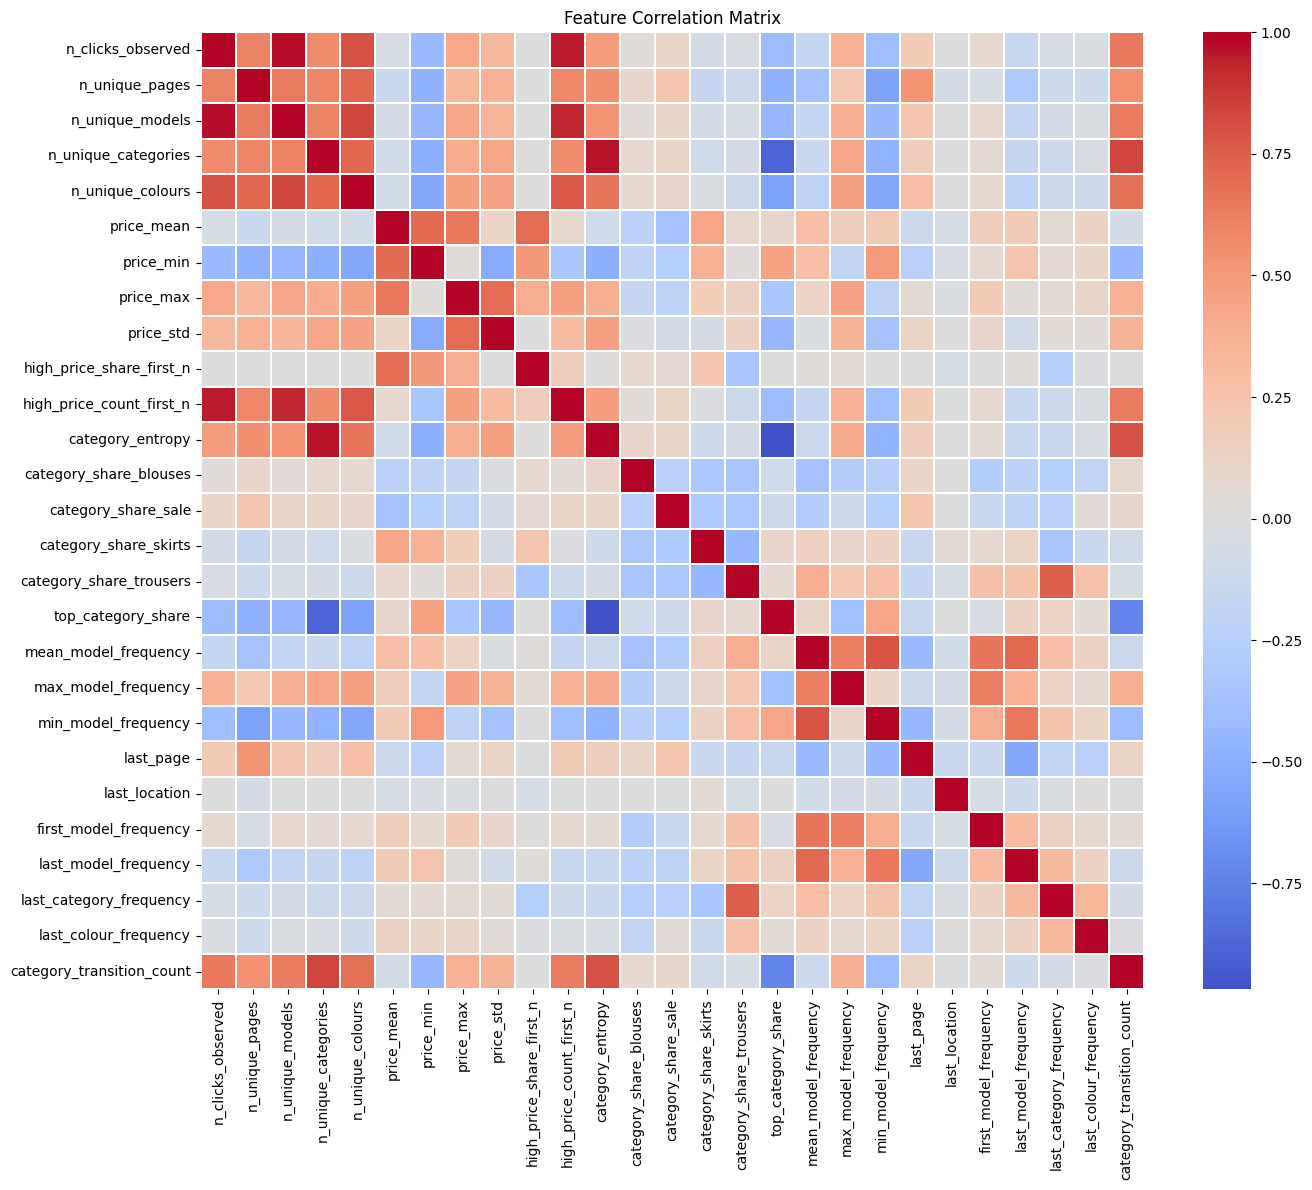

In [4]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

corr = X_scaled.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [5]:
threshold = 0.7
abs_corr = corr.abs()
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

high_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
    .query('abs_corr >= @threshold')
    .sort_values('abs_corr', ascending=False)
    .reset_index(drop=True)
)

print(f'Highly correlated pairs (|corr| >= {threshold}): {len(high_pairs)}')
display(high_pairs.head(50))

Highly correlated pairs (|corr| >= 0.7): 18


,feature_1,feature_2,abs_corr
0,n_clicks_observed,n_unique_models,0.971397
1,category_entropy,top_category_share,0.967775
2,n_unique_categories,category_entropy,0.963539
3,n_clicks_observed,high_price_count_first_n,0.950657
4,n_unique_models,high_price_count_first_n,0.929033
5,n_unique_categories,top_category_share,0.881008
6,n_unique_categories,category_transition_count,0.843466
7,n_unique_models,n_unique_colours,0.836514
8,category_entropy,category_transition_count,0.799522
9,n_clicks_observed,n_unique_colours,0.795852


In [6]:
to_drop_auto = [col for col in upper.columns if (upper[col] >= threshold).any()]
print('Auto drop candidates:', len(to_drop_auto))
display(pd.DataFrame({'feature_to_drop': to_drop_auto}).head(100))

Auto drop candidates: 10


,feature_to_drop
0,n_unique_models
1,n_unique_colours
2,price_min
3,high_price_count_first_n
4,category_entropy
5,top_category_share
6,min_model_frequency
7,last_model_frequency
8,last_category_frequency
9,category_transition_count


In [7]:
# Option A: use auto candidates
selected_drop_list = to_drop_auto

# Option B: customize manually
# selected_drop_list = ['feature_name_1', 'feature_name_2']

X_filtered = X.drop(columns=selected_drop_list, errors='ignore')
print('Original feature count:', X.shape[1])
print('Dropped feature count:', len(selected_drop_list))
print('Filtered feature count:', X_filtered.shape[1])

Original feature count: 27
Dropped feature count: 10
Filtered feature count: 17


In [8]:
from sklearn.feature_selection import VarianceThreshold

# min variance threshold (adjust as needed)
min_variance = 1e-6

vt = VarianceThreshold(threshold=min_variance)
vt.fit(X_filtered)

# features removed due to low variance
low_var = [c for c, keep in zip(X_filtered.columns, vt.get_support()) if not keep]
print(f"Low-variance features removed: {len(low_var)}", low_var)

# keep filtered features
X_filtered = X_filtered.loc[:, vt.get_support()]

Low-variance features removed: 0 []


## Explore number of clusters (k)
Evaluate clustering quality across a range of `k` values using:
- silhouette score (higher is better)
- inertia (lower is better)
- calinski-harabasz (higher is better)
- davies-bouldin (lower is better)

In [9]:
k_values = list(range(2, 31, 2))
eval_df = pd.concat([df[['session_id']], X_filtered], axis=1)

X_eval = eval_df.drop(columns=['session_id'])
X_scaled = StandardScaler().fit_transform(X_eval)

rows = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    rows.append(
        {
            'k': k,
            'silhouette_score': silhouette_score(X_scaled, labels),
            'inertia': model.inertia_,
            'calinski_harabasz_score': calinski_harabasz_score(X_scaled, labels),
            'davies_bouldin_score': davies_bouldin_score(X_scaled, labels),
        }
    )

k_metrics = pd.DataFrame(rows)
display(k_metrics)

,k,silhouette_score,inertia,calinski_harabasz_score,davies_bouldin_score
0,2,0.144076,350275.686954,3989.400282,2.352617
1,4,0.170470,274003.159372,3928.786910,1.762980
2,6,0.183872,235071.703023,3543.060967,1.718801
3,8,0.169625,214544.295592,3100.950034,1.816651
4,10,0.164929,199217.417938,2802.501990,1.772996
5,12,0.173676,188986.267538,2535.068696,1.773487
6,14,0.172892,177096.915454,2412.872741,1.739643
7,16,0.179120,167069.904989,2312.547490,1.719420
8,18,0.185493,159465.723089,2204.946392,1.671947
9,20,0.184268,153635.173735,2095.497031,1.665311


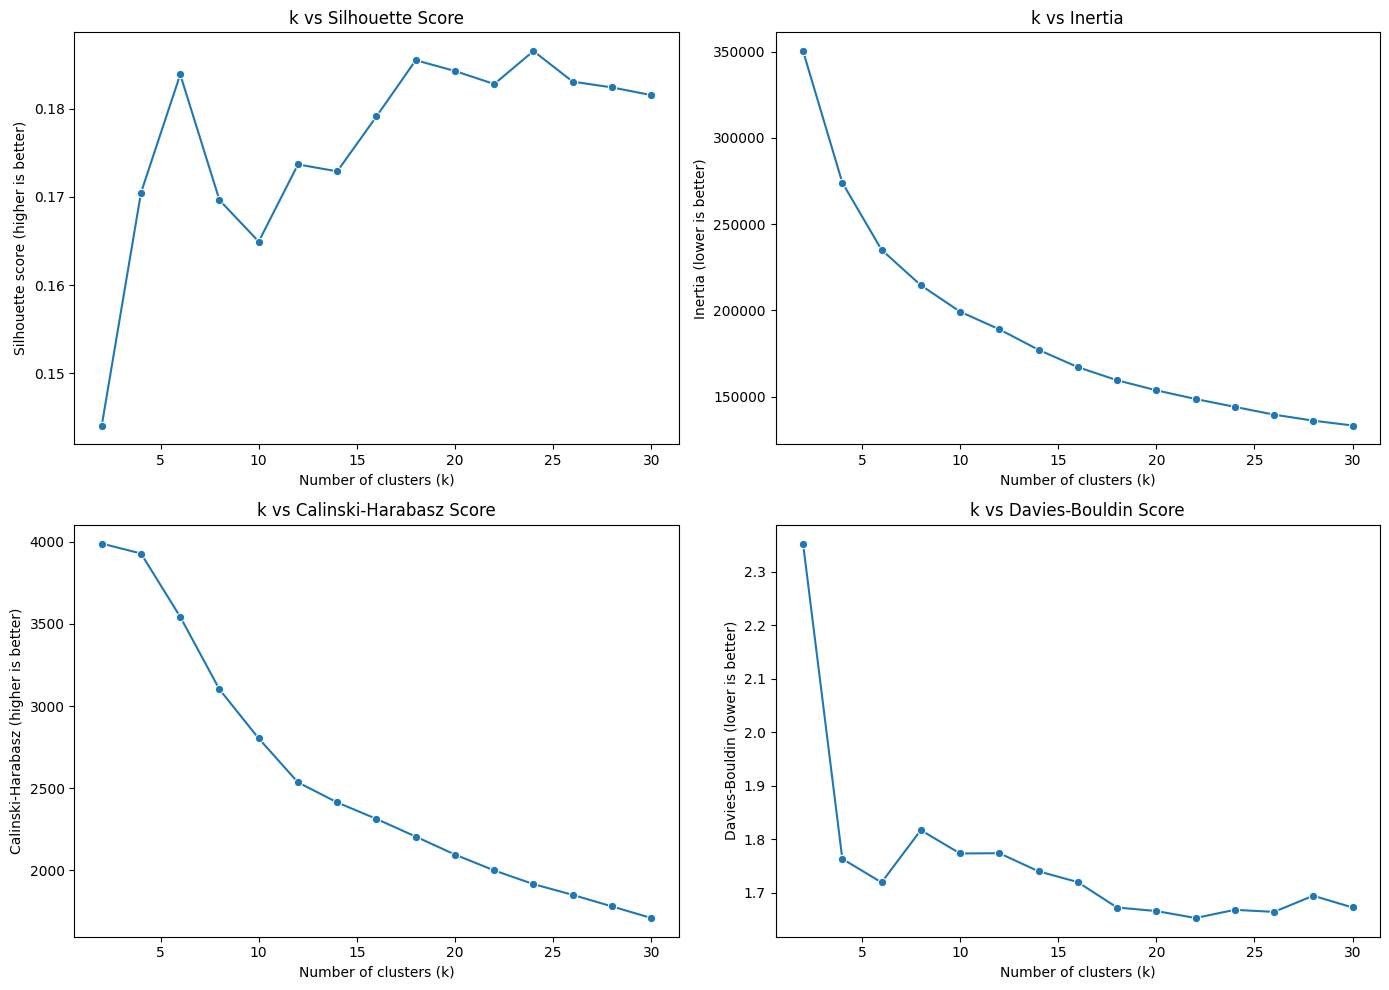

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.lineplot(data=k_metrics, x='k', y='silhouette_score', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('k vs Silhouette Score')
axes[0, 0].set_xlabel('Number of clusters (k)')
axes[0, 0].set_ylabel('Silhouette score (higher is better)')

sns.lineplot(data=k_metrics, x='k', y='inertia', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('k vs Inertia')
axes[0, 1].set_xlabel('Number of clusters (k)')
axes[0, 1].set_ylabel('Inertia (lower is better)')

sns.lineplot(data=k_metrics, x='k', y='calinski_harabasz_score', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('k vs Calinski-Harabasz Score')
axes[1, 0].set_xlabel('Number of clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz (higher is better)')

sns.lineplot(data=k_metrics, x='k', y='davies_bouldin_score', marker='o', ax=axes[1, 1])
axes[1, 1].set_title('k vs Davies-Bouldin Score')
axes[1, 1].set_xlabel('Number of clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin (lower is better)')

plt.tight_layout()
plt.show()

## Next step
Run clustering on the filtered file (if exported):

`uv run python -m online_retail_prediction.modeling.cluster_labeling_cli --features-path data/cluster_outputs/features_filtered_for_clustering.csv --output-dir data/cluster_outputs`

Or run direct pruning in CLI:

`uv run python -m online_retail_prediction.modeling.cluster_labeling_cli --features-path data/processed/features_full_session.csv --drop-correlated --output-dir data/cluster_outputs`

`k` and `correlation_threshold` are configured in `online_retail_prediction/modeling/cluster_config.py`.